In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/product_sales_clean.csv')

1. VISIÓN GENERAL DEL DATASET

In [ ]:
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nPeríodo de datos: {df['Order_Date'].min()} a {df['Order_Date'].max()}")
print(f"Clientes únicos: {df['Customer_ID_Numeric'].nunique():,}")
print(f"Órdenes únicas: {df['Order_ID'].nunique():,}")

Dimensiones: 200000 filas × 16 columnas

Período de datos: 01-01-23 a 12-31-24
Clientes únicos: 197,000
Órdenes únicas: 200,000


2. TIPOS DE DATOS Y MISSING VALUES

In [ ]:
print(df.dtypes)
print("\nValores faltantes:")
print(df.isnull().sum())

Order_ID                 int64
Order_Date              object
Customer_Name           object
City                    object
State                   object
Region                  object
Country                 object
Category                object
Sub_Category            object
Product_Name            object
Quantity                 int64
Unit_Price             float64
Revenue                float64
Profit                 float64
Customer_ID             object
Customer_ID_Numeric      int64
dtype: object

Valores faltantes:
Order_ID               0
Order_Date             0
Customer_Name          0
City                   0
State                  0
Region                 0
Country                0
Category               0
Sub_Category           0
Product_Name           0
Quantity               0
Unit_Price             0
Revenue                0
Profit                 0
Customer_ID            0
Customer_ID_Numeric    0
dtype: int64


3. ESTADÍSTICAS BÁSICAS

In [ ]:
print(df[['Quantity', 'Unit_Price', 'Revenue', 'Profit']].describe())


            Quantity     Unit_Price        Revenue         Profit
count  200000.000000  200000.000000  200000.000000  200000.000000
mean        1.854000     382.855615     712.038725     157.743041
std         1.100536     276.870235     742.471556     155.689581
min         1.000000      17.030000      17.030000       3.920000
25%         1.000000     162.760000     229.187500      59.210000
50%         1.000000     303.545000     464.880000     109.530000
75%         2.000000     562.252500     881.302500     199.402500
max        11.000000    1432.000000    9014.250000    2763.720000


4. ANÁLISIS DE REVENUE Y PROFIT

In [ ]:
print(f"Ingresos totales: ${df['Revenue'].sum():,.2f}")
print(f"Ganancia total: ${df['Profit'].sum():,.2f}")
print(f"Margen de ganancia promedio: {(df['Profit'].sum() / df['Revenue'].sum() * 100):.2f}%")

Ingresos totales: $142,407,744.93
Ganancia total: $31,548,608.13
Margen de ganancia promedio: 22.15%


5. DISTRIBUCIÓN POR CATEGORÍA

In [ ]:
category_analysis = df.groupby('Category').agg({
    'Order_ID': 'count',
    'Revenue': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).rename(columns={'Order_ID': 'Orders'})
category_analysis['Avg_Order_Value'] = category_analysis['Revenue'] / category_analysis['Orders']
category_analysis = category_analysis.sort_values('Revenue', ascending=False)
print(category_analysis)


                    Orders      Revenue       Profit  Quantity  \
Category                                                         
Electronics          51230  57485698.06   8065113.92     97115   
Home & Furniture     50564  47674426.96  11218596.44     90403   
Clothing & Apparel   62298  27134365.30   8826851.49    115523   
Accessories          35908  10113254.61   3438046.28     67759   

                    Avg_Order_Value  
Category                             
Electronics             1122.110054  
Home & Furniture         942.853156  
Clothing & Apparel       435.557567  
Accessories              281.643495  


6. DISTRIBUCIÓN POR REGIÓN

In [ ]:
region_analysis = df.groupby('Region').agg({
    'Order_ID': 'count',
    'Revenue': 'sum',
    'Profit': 'sum'
}).rename(columns={'Order_ID': 'Orders'})
region_analysis = region_analysis.sort_values('Revenue', ascending=False)
print(region_analysis)

        Orders      Revenue      Profit
Region                                 
East     57034  44980048.22  9221327.43
West     55428  36242841.73  8313962.76
Centre   49603  36081894.34  8094863.77
South    37935  25102960.64  5918454.17


7. ANÁLISIS DE CLIENTES

In [ ]:
customer_summary = df.groupby('Customer_ID_Numeric').agg({
    'Order_ID': 'count',
    'Revenue': 'sum',
    'Profit': 'sum',
    'Order_Date': ['min', 'max']
}).reset_index()

customer_summary.columns = ['Customer_ID_Numeric', 'Num_Orders', 'Total_Revenue', 'Total_Profit', 'First_Order', 'Last_Order']

print(f"Órdenes por cliente:")
print(customer_summary['Num_Orders'].describe())
print(f"\nRevenue por cliente:")
print(customer_summary['Total_Revenue'].describe())

Órdenes por cliente:
count    197000.000000
mean          1.015228
std           0.130098
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           5.000000
Name: Num_Orders, dtype: float64

Revenue por cliente:
count    197000.000000
mean        722.881954
std         753.634617
min          17.030000
25%         231.560000
50%         471.975000
75%         893.340000
max        9014.250000
Name: Total_Revenue, dtype: float64


8. VISUALIZACIONES

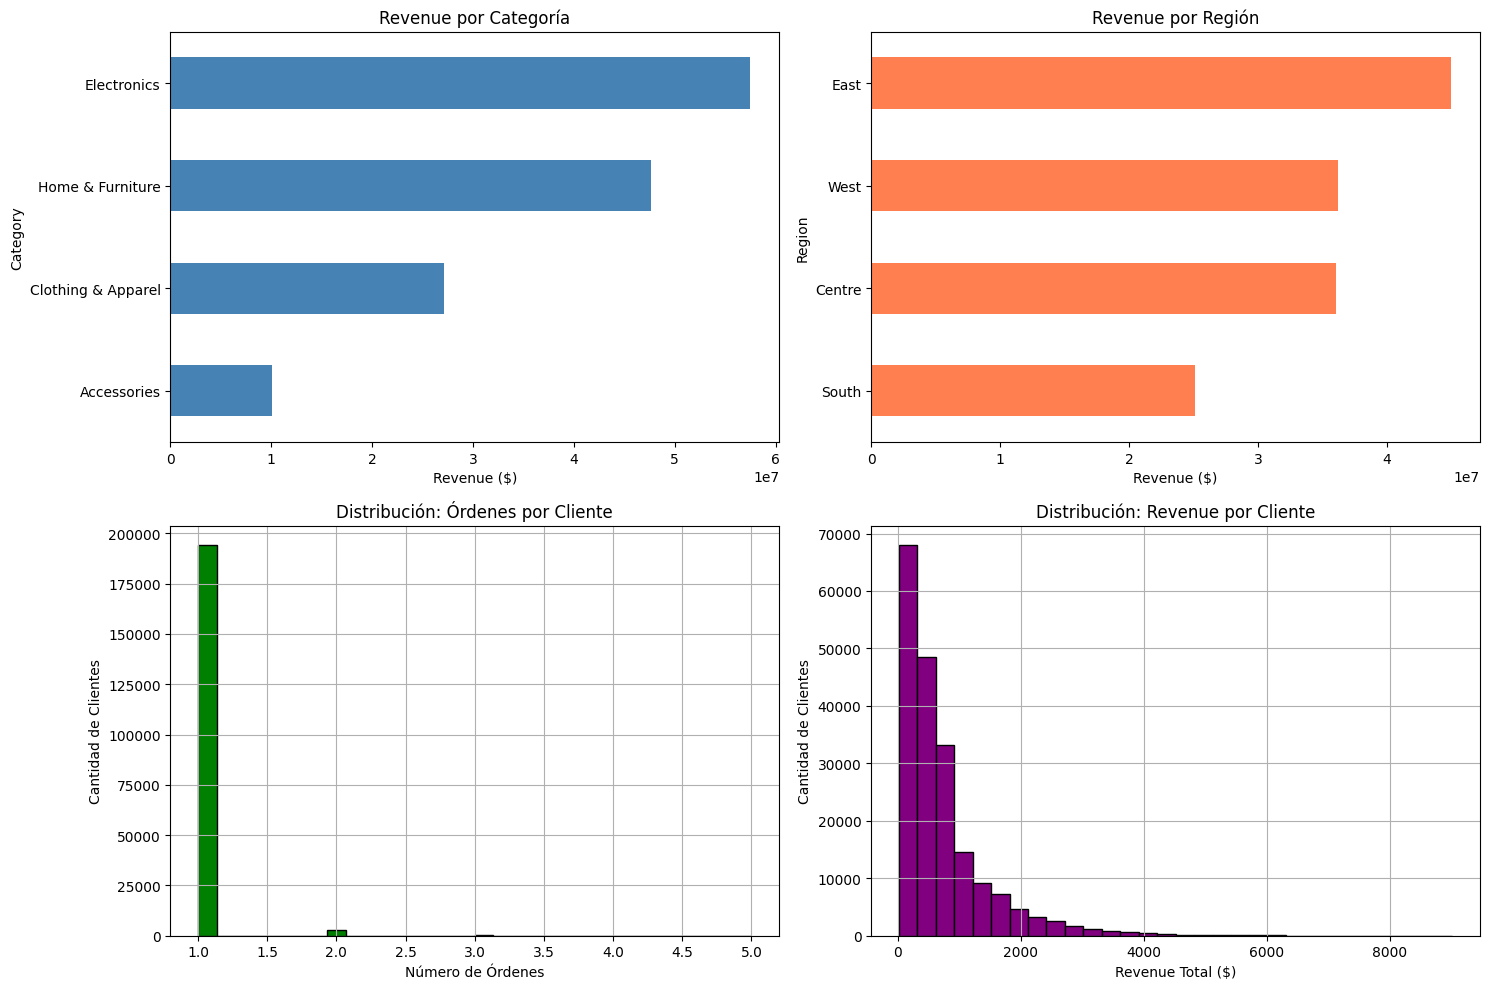

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Revenue por categoría
df.groupby('Category')['Revenue'].sum().sort_values().plot(kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Revenue por Categoría')
axes[0, 0].set_xlabel('Revenue ($)')

# Revenue por región
df.groupby('Region')['Revenue'].sum().sort_values().plot(kind='barh', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Revenue por Región')
axes[0, 1].set_xlabel('Revenue ($)')

# Distribución de órdenes por cliente
customer_summary['Num_Orders'].hist(bins=30, ax=axes[1, 0], color='green', edgecolor='black')
axes[1, 0].set_title('Distribución: Órdenes por Cliente')
axes[1, 0].set_xlabel('Número de Órdenes')
axes[1, 0].set_ylabel('Cantidad de Clientes')

# Distribución de revenue por cliente
customer_summary['Total_Revenue'].hist(bins=30, ax=axes[1, 1], color='purple', edgecolor='black')
axes[1, 1].set_title('Distribución: Revenue por Cliente')
axes[1, 1].set_xlabel('Revenue Total ($)')
axes[1, 1].set_ylabel('Cantidad de Clientes')

plt.tight_layout()
plt.show()

9. INSIGHTS CLAVE

In [ ]:
top_customers = customer_summary.nlargest(10, 'Total_Revenue')
print(f"Top 10 clientes generan ${top_customers['Total_Revenue'].sum():,.2f}")
print(f"Eso representa {(top_customers['Total_Revenue'].sum() / customer_summary['Total_Revenue'].sum() * 100):.1f}% del revenue total")

print(f"\nClientes con 1 sola orden: {(customer_summary['Num_Orders'] == 1).sum()}")
print(f"Clientes con 5+ órdenes: {(customer_summary['Num_Orders'] >= 4).sum()}")

Top 10 clientes generan $85,009.80
Eso representa 0.1% del revenue total

Clientes con 1 sola orden: 194176
Clientes con 5+ órdenes: 12


In [ ]:
customer_summary.to_csv('customer_summary.csv', index=False)
print("\n Tabla de clientes guardada como 'customer_summary.csv'")